### Script to generate FATES parameters using LHS

In [1]:
from scipy.stats import qmc
import numpy as np

import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys
import shutil
from tempfile import TemporaryFile                                                                                                                                 
import argparse                                                                                                                                                                                                                                                                                                       
import tempfile 
import random
import re

import modp as mp

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import cartopy.crs as ccrs
import cartopy.feature as cf
from matplotlib import cm


In [2]:
random.seed(32)

#### Read in min and max values for each parameter and pft 

In [3]:
param_ranges_full = pd.read_csv('/global/homes/j/jneedham/FATES-MRV/param_files/PA_params_2pfts.csv')
param_ranges = param_ranges_full[['param', 'value_min', 'value_max', 'pft', 'organ']]

# number of parameters
n_params = len(param_ranges)

# number of PFTs - some are global so subtract one
n_pfts = len(pd.unique(param_ranges['pft'])) - 1

param_names = list(param_ranges.param)
pfts = list(param_ranges.pft)
organs = list(param_ranges.organ)

print(param_ranges)

                                      param   value_min   value_max  pft  \
0          fates_maintresp_nonleaf_baserate    0.000002    0.000003    0   
1              fates_mort_understorey_death    0.000000    1.000000    0   
2                   fates_mort_disturb_frac    0.300000    1.000000    0   
3   fates_maintresp_leaf_vert_scaler_coeff2    1.600000    2.430000    2   
4   fates_maintresp_leaf_vert_scaler_coeff2    1.600000    2.430000    1   
5   fates_maintresp_leaf_atkin2017_baserate    1.317000    2.195000    2   
6   fates_maintresp_leaf_atkin2017_baserate    1.317000    2.195000    1   
7                         fates_leaf_slatop    0.022500    0.037500    2   
8                         fates_leaf_slatop    0.022500    0.037500    1   
9               fates_alloc_storage_cushion    1.800000    3.000000    2   
10              fates_alloc_storage_cushion    1.800000    3.000000    1   
11                         fates_mort_bmort    0.010500    0.017500    2   
12          

In [4]:
n_inst = 500

sampler = qmc.LatinHypercube(d=n_params)
sample = sampler.random(n=n_inst)

# scale to parameter ranges
l_bounds = param_ranges['value_min']
u_bounds = param_ranges['value_max']

scaled_sample = qmc.scale(sample, l_bounds, u_bounds)

In [5]:
npft1 = param_ranges['pft'].value_counts().get(1, 0)

print(npft1)

10


In [6]:
rows, cols = n_inst, npft1

df = pd.DataFrame(np.nan, index=range(rows), columns=range(cols))

## Read in defaut FATES file - note that this is the default for FATES but with:
#  two stream radiation
# Atkin respiration
# Updated allometries for Eastern US trees 

input_fname = '/global/homes/j/jneedham/FATES-MRV/param_files/fates_params_2pfts_PA.nc'


# for each sample 
for i in range(0,n_inst) :
    
    # final parameter file name
    fout = '/global/homes/j/jneedham/FATES-MRV/param_files/fates_params_2pfts_pa_ens_{0}.nc'.format(i+1)
    
    shutil.copyfile(input_fname, fout)   
    
    pft1_ind = 0

   
    # loop through each parameter and apply either to the correct pft or globally
    for j in range(0, n_params) : 
        
        pft = pfts[j]
        organ = organs[j]
        val = scaled_sample[i, j]
        var = param_names[j]
        
        if pft == 1:
            
            # Parameters where PFT 1 val should be higher 
            if var in ['fates_maintresp_leaf_vert_scaler_coeff2',
                       'fates_maintresp_leaf_atkin2017_baserate',
                       'fates_leaf_slatop', 
                       'fates_mort_bmort', 
                       'fates_mort_scalar_cstarvation', 
                       'fates_recruit_seed_alloc',
                       'fates_leaf_vcmax25top'] : 
            
                minv = scaled_sample[i, j-1]
                maxv = param_ranges['value_max'][j]
            
            # remaining PFT level parameters have higher value for PFT 2
            else:
                
                maxv = scaled_sample[i, j-1]
                minv = param_ranges['value_min'][j]
            
            pft1val = random.uniform(minv, maxv)
            mp.main(var = var, pft = pft, fin = fout, val = pft1val, 
                    fout = fout, O = 1, organ = organ)
            
            df.iloc[i, pft1_ind] = pft1val
            
            pft1_ind = pft1_ind + 1
        
        
        else:
            mp.main(var = var, pft = pft, fin = fout, val = val, 
                        fout = fout, O = 1, organ = organ)
        
        
       
            
    

### Plot some of the trade-offs

In [7]:
print(scaled_sample.shape)

(500, 23)


In [8]:
samplesdf = pd.DataFrame(scaled_sample)
samplesdf.columns = [i+str(j) for i,j in zip(param_ranges['param'], param_ranges['pft'])]
#print(samplesdf.head(3))

df.columns = [s for s in samplesdf.columns if s.endswith('1')]
print([s for s in samplesdf.columns if '1' in s])


['fates_maintresp_leaf_vert_scaler_coeff21', 'fates_maintresp_leaf_atkin2017_baserate2', 'fates_maintresp_leaf_atkin2017_baserate1', 'fates_leaf_slatop1', 'fates_alloc_storage_cushion1', 'fates_mort_bmort1', 'fates_mort_scalar_cstarvation1', 'fates_recruit_seed_alloc1', 'fates_recruit_seed_dbh_repro_threshold1', 'fates_turnover_branch1', 'fates_leaf_vcmax25top1']


In [9]:
samplesdf.update(df)

#print(samplesdf.head(3))

In [10]:
## save the csvs
samplesdf.to_csv('/global/homes/j/jneedham/FATES-MRV/param_files/2pft_samples.csv', index=False)

Text(0, 0.5, 'pft 1 - early')

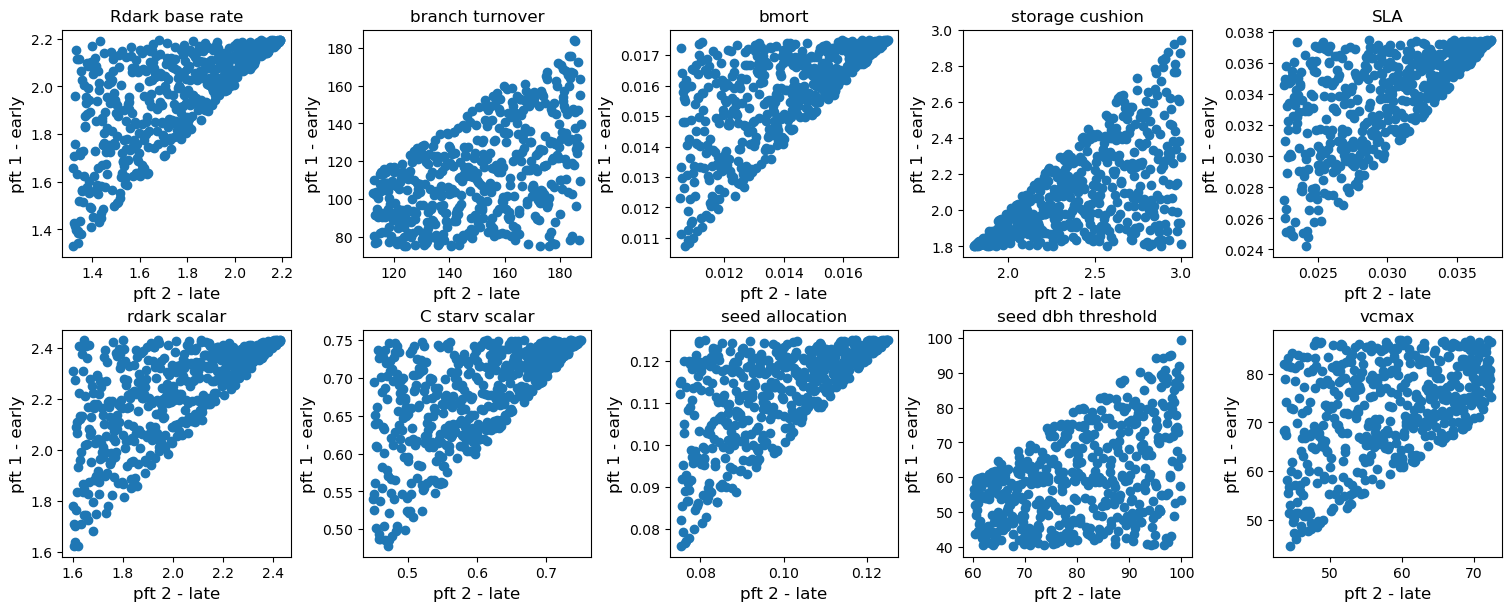

In [11]:
fig, ((fax0,fax1,fax2,fax3,fax4),(fax5,fax6,fax7,fax8,fax9)) = plt.subplots(nrows=2, ncols=5,figsize=(15,6), constrained_layout=True)

fax0.scatter(samplesdf['fates_maintresp_leaf_atkin2017_baserate2'], samplesdf['fates_maintresp_leaf_atkin2017_baserate1'])
fax0.set_title('Rdark base rate', fontsize=12)
fax0.set_xlabel('pft 2 - late', fontsize=12)
fax0.set_ylabel('pft 1 - early', fontsize=12)

fax1.scatter(samplesdf['fates_turnover_branch2'], samplesdf['fates_turnover_branch1'])
fax1.set_title('branch turnover', fontsize=12)
fax1.set_xlabel('pft 2 - late', fontsize=12)
fax1.set_ylabel('pft 1 - early', fontsize=12)

fax2.scatter(samplesdf['fates_mort_bmort2'], samplesdf['fates_mort_bmort1'])
fax2.set_title('bmort', fontsize=12)
fax2.set_xlabel('pft 2 - late', fontsize=12)
fax2.set_ylabel('pft 1 - early', fontsize=12)

fax3.scatter(samplesdf['fates_alloc_storage_cushion2'], samplesdf['fates_alloc_storage_cushion1'])
fax3.set_title('storage cushion', fontsize=12)
fax3.set_xlabel('pft 2 - late', fontsize=12)
fax3.set_ylabel('pft 1 - early', fontsize=12)

fax4.scatter(samplesdf['fates_leaf_slatop2'], samplesdf['fates_leaf_slatop1'])
fax4.set_title('SLA', fontsize=12)
fax4.set_xlabel('pft 2 - late', fontsize=12)
fax4.set_ylabel('pft 1 - early', fontsize=12)

fax5.scatter(samplesdf['fates_maintresp_leaf_vert_scaler_coeff22'], samplesdf['fates_maintresp_leaf_vert_scaler_coeff21'])
fax5.set_title('rdark scalar', fontsize=12)
fax5.set_xlabel('pft 2 - late', fontsize=12)
fax5.set_ylabel('pft 1 - early', fontsize=12)

fax6.scatter(samplesdf['fates_mort_scalar_cstarvation2'], samplesdf['fates_mort_scalar_cstarvation1'])
fax6.set_title('C starv scalar', fontsize=12)
fax6.set_xlabel('pft 2 - late', fontsize=12)
fax6.set_ylabel('pft 1 - early', fontsize=12)

fax7.scatter(samplesdf['fates_recruit_seed_alloc2'], samplesdf['fates_recruit_seed_alloc1'])
fax7.set_title('seed allocation', fontsize=12)
fax7.set_xlabel('pft 2 - late', fontsize=12)
fax7.set_ylabel('pft 1 - early', fontsize=12)

fax8.scatter(samplesdf['fates_recruit_seed_dbh_repro_threshold2'], samplesdf['fates_recruit_seed_dbh_repro_threshold1'])
fax8.set_title('seed dbh threshold', fontsize=12)
fax8.set_xlabel('pft 2 - late', fontsize=12)
fax8.set_ylabel('pft 1 - early', fontsize=12)

fax9.scatter(samplesdf['fates_leaf_vcmax25top2'], samplesdf['fates_leaf_vcmax25top1'])
fax9.set_title('vcmax', fontsize=12)
fax9.set_xlabel('pft 2 - late', fontsize=12)
fax9.set_ylabel('pft 1 - early', fontsize=12)

